In [40]:
using Plots
using SpecialFunctions
using LaTeXStrings
using Measures #Uso para margenes y espacios  
using JLD2 #guardar datos
# --- Parameters ---
g = 1.0           
t_fin = 4.0       
j_vals = -9:10   
t_vals = range(0.0, t_max, length=17)

# The exact density for two non-interacting bosons starting at 0 and 1
function exact_density(j, t, g)
    x = -2.0 * g * t
    return abs2(besselj(j, x)) + abs2(besselj(j - 1, x))
end

# Preallocate the matrix
Z = zeros(length(t_vals), length(j_vals))

# Populate the matrix
for (col, j) in enumerate(j_vals)
    for (row, t) in enumerate(t_vals)
        Z[row, col] = exact_density(j, t, g)
    end
end

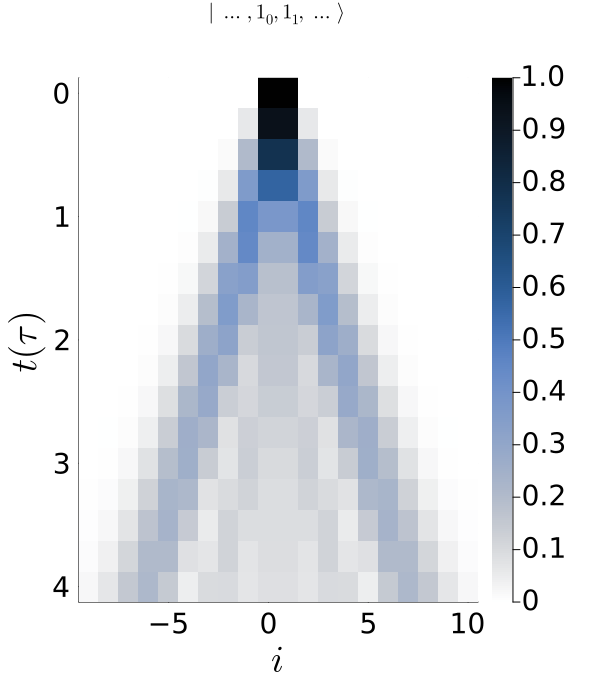

In [41]:
# --- Generate the Heatmap --- 
Tperiod = t_fin
y_full_ticks = 0:0.25:Tperiod  # Rango de la cuadricula (0 a tfin con pasos de 0.25)
y_labels = vec(range(1, Tperiod + 1))     # Las etiquetas que quiero mostrar especificamente
y_label_indices = findall(x -> x in y_labels, y_full_ticks) 
heatmap(j_vals, t_vals, Z, 
        xlabel =L"i", 
        ylabel =L"t(\tau)", 
        yflip = true,
        title =L"|\dots,1_0, 1_1,\dots\rangle",
        color = cgrad(:oslo, rev=true), #cgrad([:white , :blue])
        size=(600, 700),
        #title=L"Quantum~walk~for~U = %$Uva ~ \theta = %$θ ~g = %$gva",
        colorbar_tickfontsize = font(10),
        # fuentes
        guidefontsize = 25,    # Títulos de ejes (i, t) 
        colorbar_titlefontsize = 24, #Tamaño de la barra de calor
        tickfontsize = 19, top_margin = 11mm, right_margin = 11mm, 
        colorbar=true)

In [43]:
save_object("qwalk0110.jld2", Z)